# Exploratory Simulations: Stuart–Landau Model and Coupled Oscillator Synchronization
**Author:** Maroua Ouahbi

This notebook is organised into three parts:
1. **Single Stuart–Landau oscillator** — limit cycle, Hopf bifurcation, parameter effects
2. **Two coupled phase oscillators (Kuramoto reduction)** — analytical synchronization condition vs simulation
3. **Two coupled Stuart–Landau oscillators** — full amplitude + phase dynamics, connection to low-inertia power grids

Analytical predictions from the derivation document are overlaid on every relevant plot.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'lines.linewidth': 1.8,
})

---
## Part 1 — Single Stuart–Landau Oscillator

The Stuart–Landau equation is:

$$\frac{dA}{dt} = \sigma A - \frac{l}{2} A |A|^2$$

with $\sigma = \sigma_r + i\sigma_i$ and $l = l_r + il_i$.
Writing $A = x + iy$ gives the real-valued system used for simulation:

$$\dot{x} = \sigma_r x - \sigma_i y - \frac{l_r}{2}(x^2+y^2)x + \frac{l_i}{2}(x^2+y^2)y$$
$$\dot{y} = \sigma_i x + \sigma_r y - \frac{l_r}{2}(x^2+y^2)y - \frac{l_i}{2}(x^2+y^2)x$$

The **analytical steady-state amplitude** (limit cycle) is:

$$r^* = \sqrt{\frac{2\sigma_r}{l_r}}$$

In [2]:
# ── ODE and helper ──────────────────────────────────────────────────────────
def stuart_landau(t, z, sigma_r, sigma_i, l_r, l_i):
    x, y = z
    r2 = x**2 + y**2
    dxdt = sigma_r*x - sigma_i*y - (l_r/2)*r2*x + (l_i/2)*r2*y
    dydt = sigma_i*x + sigma_r*y - (l_r/2)*r2*y - (l_i/2)*r2*x
    return [dxdt, dydt]

def analytical_r_star(sigma_r, l_r):
    if sigma_r > 0 and l_r > 0:
        return np.sqrt(2 * sigma_r / l_r)
    return 0.0

### 1.1  Stable Limit Cycle ($\sigma_r > 0$)

When $\sigma_r > 0$ the origin is unstable and every trajectory converges to the limit cycle at $r^*$.
We test two initial conditions — one inside and one outside $r^*$ — to confirm global attraction.

Analytical limit-cycle amplitude:  r* = sqrt(2*1.0/1.0) = 1.4142


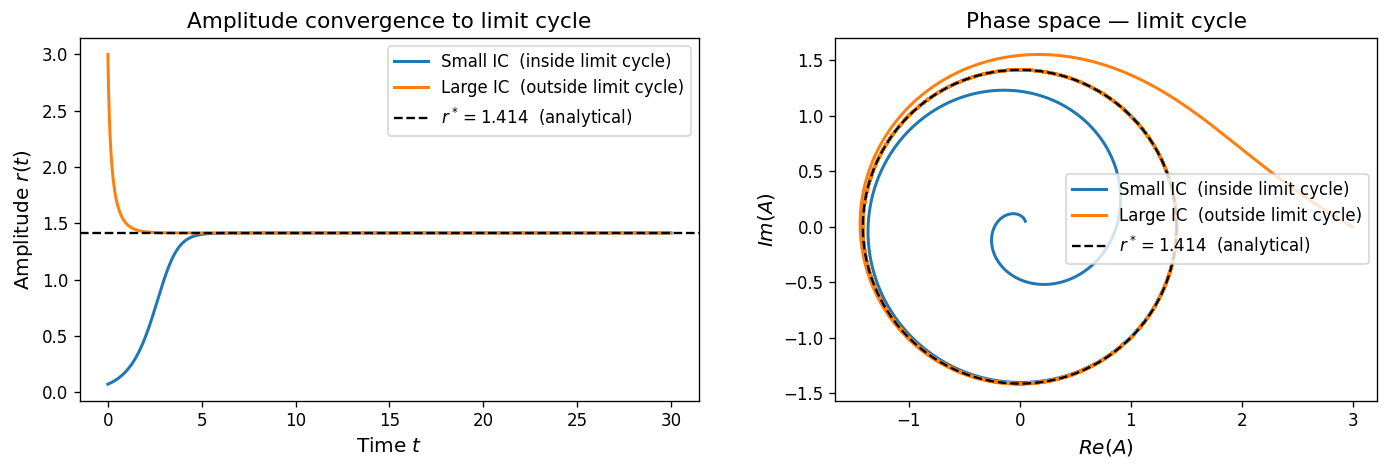

In [14]:
sigma_r, sigma_i, l_r, l_i = 1.0, 2.0, 1.0, 0.0
r_star = analytical_r_star(sigma_r, l_r)
print(f"Analytical limit-cycle amplitude:  r* = sqrt(2*{sigma_r}/{l_r}) = {r_star:.4f}")

t_span = (0, 30)
t_eval = np.linspace(*t_span, 3000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for z0, label, col in [([0.05, 0.05], "Small IC  (inside limit cycle)",  "C0"),
                        ([3.0,  0.0 ], "Large IC  (outside limit cycle)", "C1")]:
    sol = solve_ivp(
        lambda t, z: stuart_landau(t, z, sigma_r, sigma_i, l_r, l_i),
        t_span, z0, t_eval=t_eval, rtol=1e-9)
    r = np.sqrt(sol.y[0]**2 + sol.y[1]**2)
    axes[0].plot(sol.t, r, color=col, label=label)
    axes[1].plot(sol.y[0], sol.y[1], color=col, label=label)

# Analytical reference
axes[0].axhline(r_star, color='k', ls='--', lw=1.4,
                label=f"$r^* = {r_star:.3f}$  (analytical)")
axes[0].set(xlabel="Time $t$", ylabel="Amplitude $r(t)$",
            title="Amplitude convergence to limit cycle")
axes[0].legend()

theta = np.linspace(0, 2*np.pi, 300)
axes[1].plot(r_star*np.cos(theta), r_star*np.sin(theta),
             'k--', lw=1.4, label=f"$r^* = {r_star:.3f}$  (analytical)")
axes[1].set(xlabel="$Re(A)$", ylabel="$Im(A)$", title="Phase space — limit cycle")
axes[1].set_aspect('equal')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig1', dpi=300, bbox_inches='tight')
plt.show()

**Observation.** Both initial conditions converge to the analytical prediction $r^* = \sqrt{2\sigma_r/l_r}$ (dashed line).
This confirms the Hopf bifurcation picture: the origin is an unstable fixed point when $\sigma_r > 0$.

### 1.2  Stable Fixed Point ($\sigma_r < 0$)

When $\sigma_r < 0$ there is no positive-amplitude equilibrium — all trajectories decay to the origin.

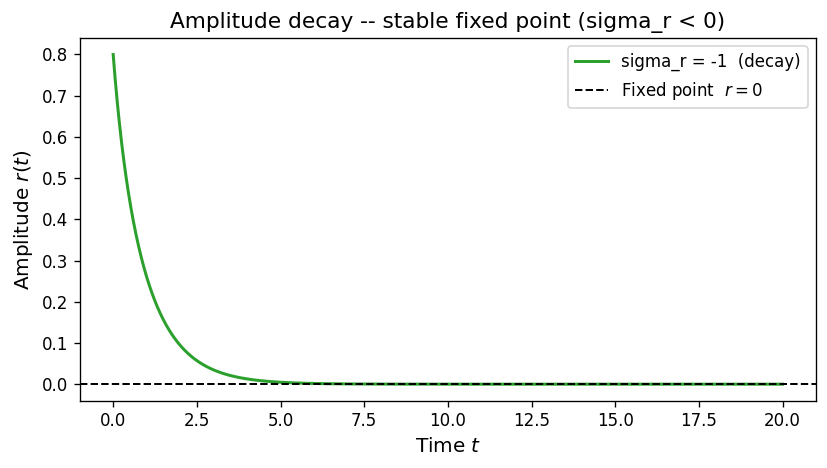

In [4]:
sigma_r_neg = -1.0
t_eval_decay = np.linspace(0, 20, 2000)

sol = solve_ivp(
    lambda t, z: stuart_landau(t, z, sigma_r_neg, 2.0, 1.0, 0.0),
    (0, 20), [0.8, 0.0], t_eval=t_eval_decay, rtol=1e-9)
r = np.sqrt(sol.y[0]**2 + sol.y[1]**2)

plt.figure(figsize=(7, 4))
plt.plot(sol.t, r, 'C2', label="sigma_r = -1  (decay)")
plt.axhline(0, color='k', ls='--', lw=1.2, label="Fixed point  $r = 0$")
plt.xlabel("Time $t$")
plt.ylabel("Amplitude $r(t)$")
plt.title("Amplitude decay -- stable fixed point (sigma_r < 0)")
plt.legend()
plt.tight_layout()
plt.savefig('fig2', dpi=300, bbox_inches='tight')
plt.show()

### 1.3  Hopf Bifurcation Diagram

We sweep $\sigma_r$ and record the steady-state amplitude, comparing simulation to $r^* = \sqrt{2\sigma_r/l_r}$.
The bifurcation occurs at $\sigma_r = 0$.

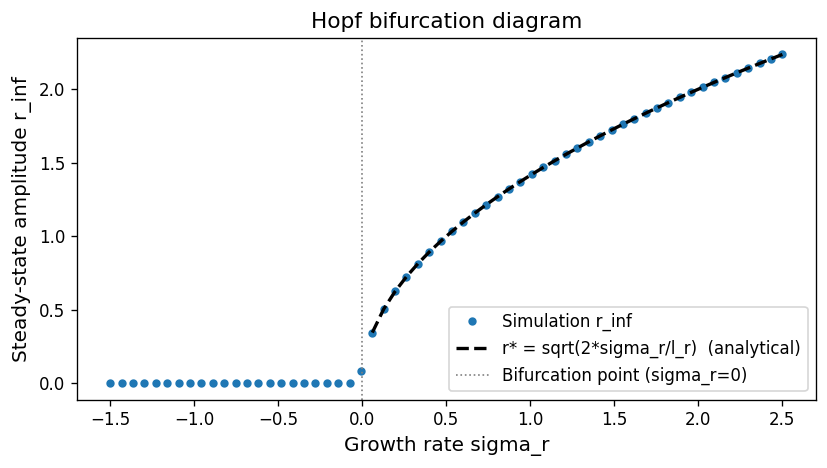

In [5]:
sigma_r_values = np.linspace(-1.5, 2.5, 60)
r_final = []

for sr in sigma_r_values:
    def rhs(t, z, sr=sr):
        x, y = z
        r2 = x**2 + y**2
        return [sr*x - 2.0*y - 0.5*r2*x,
                2.0*x + sr*y - 0.5*r2*y]

    sol = solve_ivp(rhs, (0, 60), [0.3, 0.0], t_eval=[59.9, 60.0], rtol=1e-9)
    r_final.append(np.sqrt(sol.y[0, -1]**2 + sol.y[1, -1]**2))

sr_pos = sigma_r_values[sigma_r_values >= 0]
r_theory = np.sqrt(2 * sr_pos / 1.0)

plt.figure(figsize=(7, 4))
plt.plot(sigma_r_values, r_final, 'o', ms=4, color='C0', label="Simulation r_inf")
plt.plot(sr_pos, r_theory, 'k--', lw=2,
         label="r* = sqrt(2*sigma_r/l_r)  (analytical)")
plt.axvline(0, color='gray', ls=':', lw=1, label="Bifurcation point (sigma_r=0)")
plt.xlabel("Growth rate sigma_r")
plt.ylabel("Steady-state amplitude r_inf")
plt.title("Hopf bifurcation diagram")
plt.legend()
plt.tight_layout()
plt.savefig('fig3', dpi=300, bbox_inches='tight')
plt.show()

**Observation.** For $\sigma_r < 0$ the only attractor is $r = 0$.
For $\sigma_r > 0$ the simulation matches the analytical curve exactly.
The transition at $\sigma_r = 0$ is the **supercritical Hopf bifurcation**.

---
## Part 2 — Two Coupled Phase Oscillators (Kuramoto Reduction)

When amplitudes are frozen at $r^*$, only the phase equations survive.
For two oscillators this gives the **Kuramoto pair**:

$$\dot{\phi}_1 = \omega_1 + K\sin(\phi_2 - \phi_1)$$
$$\dot{\phi}_2 = \omega_2 + K\sin(\phi_1 - \phi_2)$$

Defining the phase difference $\Delta = \phi_1 - \phi_2$:

$$\dot{\Delta} = (\omega_1 - \omega_2) - 2K\sin\Delta$$

**Analytical synchronization condition** — a fixed point exists if and only if:

$$|\omega_1 - \omega_2| \leq 2K \quad \Longleftrightarrow \quad K \geq K_c = \frac{|\omega_1 - \omega_2|}{2}$$

With $\omega_1 = 1.0$, $\omega_2 = 1.5$, the critical coupling is $K_c = 0.25$.

In [6]:
omega1, omega2 = 1.0, 1.5
delta_omega = abs(omega1 - omega2)
K_c = delta_omega / 2.0
print(f"omega1 = {omega1},  omega2 = {omega2}")
print(f"|Delta_omega| = {delta_omega},   analytical K_c = {K_c}")

def simulate_kuramoto_2(omega1, omega2, K, T=80, dt=0.005):
    t = np.arange(0, T, dt)
    phi = np.zeros((2, len(t)))
    phi[0, 0] = 0.0
    phi[1, 0] = np.pi / 4
    for i in range(len(t) - 1):
        dphi1 = omega1 + K * np.sin(phi[1, i] - phi[0, i])
        dphi2 = omega2 + K * np.sin(phi[0, i] - phi[1, i])
        phi[0, i+1] = phi[0, i] + dt * dphi1
        phi[1, i+1] = phi[1, i] + dt * dphi2
    return t, phi

omega1 = 1.0,  omega2 = 1.5
|Delta_omega| = 0.5,   analytical K_c = 0.25


### 2.1  Synchronized vs Unsynchronized: Three Coupling Regimes

We simulate the same system with three values of $K$ on the same axes so the transition is clearly visible.

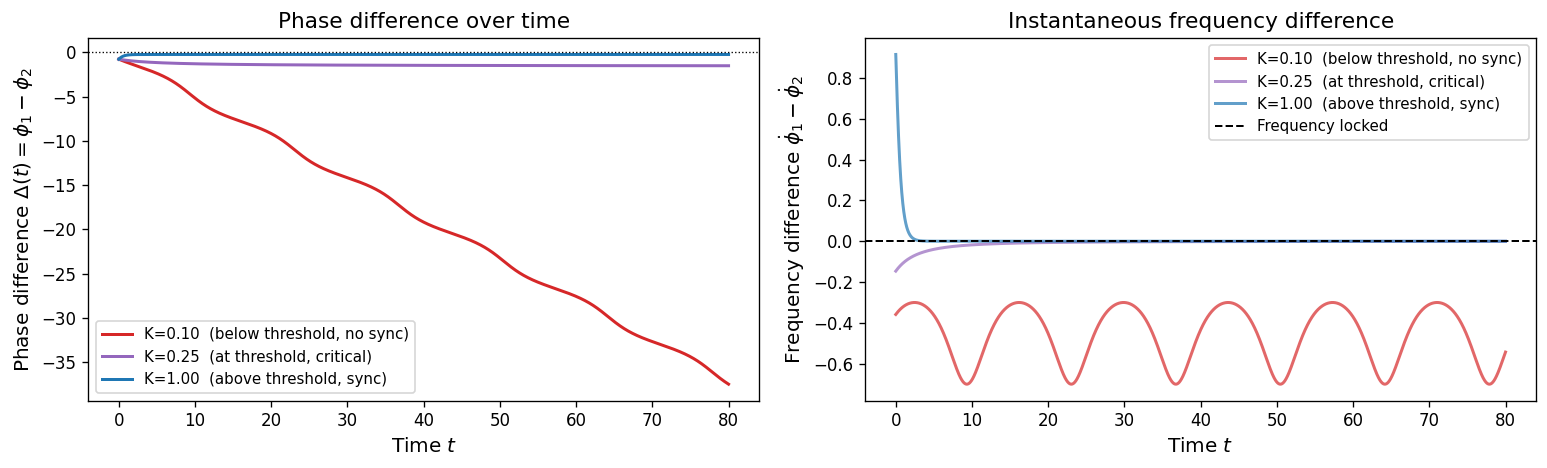

In [7]:
cases = [
    (0.10, "K=0.10  (below threshold, no sync)", "C3"),
    (0.25, "K=0.25  (at threshold, critical)",   "C4"),
    (1.00, "K=1.00  (above threshold, sync)",    "C0"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for K, label, col in cases:
    t, phi = simulate_kuramoto_2(omega1, omega2, K)
    Delta = phi[0] - phi[1]
    axes[0].plot(t, Delta, color=col, label=label)

    # Instantaneous frequency of each oscillator
    freq1 = np.gradient(phi[0], t)
    freq2 = np.gradient(phi[1], t)
    axes[1].plot(t, freq1 - freq2, color=col, alpha=0.7, label=label)

axes[0].axhline(0, color='k', ls=':', lw=0.8)
axes[0].set(xlabel="Time $t$",
            ylabel=r"Phase difference $\Delta(t) = \phi_1 - \phi_2$",
            title="Phase difference over time")
axes[0].legend(fontsize=9)

axes[1].axhline(0, color='k', ls='--', lw=1.2, label="Frequency locked")
axes[1].set(xlabel="Time $t$",
            ylabel=r"Frequency difference $\dot{\phi}_1 - \dot{\phi}_2$",
            title="Instantaneous frequency difference")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('2cpld_kur_rdact_fig1', dpi=300, bbox_inches='tight')
plt.show()

**Observation.**
- $K = 0.10 < K_c$: phase difference grows without bound — **no synchronization**.
- $K = 0.25 = K_c$: borderline case, very slow convergence (saddle-node bifurcation on a circle).
- $K = 1.00 > K_c$: $\Delta(t)$ rapidly converges to a constant — **stable synchronization**.

In power grid terms, $K$ is the line susceptance. The condition says the line must be strong enough relative to the generator frequency mismatch to maintain grid coherence.

### 2.2  Analytical Equilibrium Phase Difference

At the synchronized fixed point $\dot{\Delta} = 0$:

$$\sin\Delta^* = \frac{\omega_1 - \omega_2}{2K} \implies \Delta^* = \arcsin\!\left(\frac{\omega_1-\omega_2}{2K}\right)$$

We compare this analytical curve with the simulated steady-state phase difference.

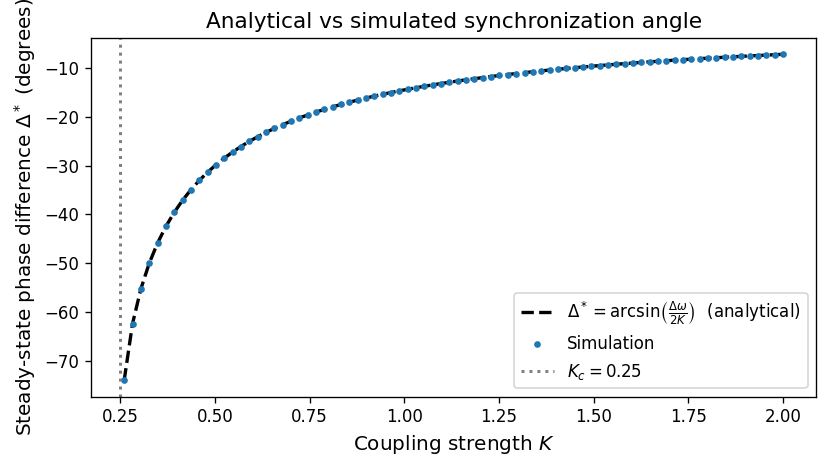

In [8]:
K_vals = np.linspace(K_c + 0.01, 2.0, 80)
delta_analytical = np.arcsin((omega1 - omega2) / (2 * K_vals))
delta_simulated  = []

for K in K_vals:
    t, phi = simulate_kuramoto_2(omega1, omega2, K, T=120, dt=0.005)
    # Average over last 10% of simulation to get steady state
    n_avg = len(t) // 10
    delta_simulated.append(np.mean((phi[0] - phi[1])[-n_avg:]))

plt.figure(figsize=(7, 4))
plt.plot(K_vals, np.degrees(delta_analytical), 'k--', lw=2,
         label=r"$\Delta^* = \arcsin\!\left(\frac{\Delta\omega}{2K}\right)$  (analytical)")
plt.plot(K_vals, np.degrees(delta_simulated), 'C0o', ms=3, label="Simulation")
plt.axvline(K_c, color='gray', ls=':', label=f"$K_c = {K_c}$")
plt.xlabel("Coupling strength $K$")
plt.ylabel(r"Steady-state phase difference $\Delta^*$ (degrees)")
plt.title("Analytical vs simulated synchronization angle")
plt.legend()
plt.tight_layout()
plt.savefig('2cpld_kur_rdact_fig2', dpi=300, bbox_inches='tight')
plt.show()

**Observation.** Simulation matches the analytical formula $\Delta^* = \arcsin(\Delta\omega / 2K)$ exactly for all $K > K_c$.
As $K \to K_c^+$, $|\Delta^*| \to 90°$ — this is the stability boundary.

---
## Part 3 — Two Coupled Stuart–Landau Oscillators (Full Model)

The Kuramoto reduction assumes amplitudes are fixed. In reality — especially in **low-inertia power grids** — amplitudes can vary rapidly.

The full coupled Stuart–Landau system on a two-node network is:

$$\frac{dA_i}{dt} = \sigma A_i - \frac{l}{2} A_i |A_i|^2 + K(A_j - A_i), \quad i \neq j$$

The coupling term $K(A_j - A_i)$ is **diffusive (Laplacian) coupling**. For a general network of $N$ oscillators the equations generalise to:

$$\frac{dA_i}{dt} = \sigma A_i - \frac{l}{2}A_i|A_i|^2 - \sum_{j=1}^N \mathcal{L}_{ij} A_j$$

where $\mathcal{L}$ is the **graph Laplacian**:

$$\mathcal{L}_{ij} = \begin{cases} \sum_{k \neq i} K_{ik} & i = j \\ -K_{ij} & i \neq j \end{cases}$$

For our two-node case: $\mathcal{L} = K\begin{pmatrix}1 & -1 \\ -1 & 1\end{pmatrix}$

In a real power grid, $K_{ij} = 0$ unless a physical transmission line connects buses $i$ and $j$ — the network is **sparse**.

Writing $A_i = x_i + iy_i$, the four real ODEs are implemented below.

In [9]:
def coupled_SL_rhs(t, z, sigma_r, sigma_i1, sigma_i2, l_r, K):
    """
    Two coupled Stuart-Landau oscillators in Cartesian coordinates.
    State: z = [x1, y1, x2, y2]
    Each oscillator has its own natural frequency (sigma_i1, sigma_i2).
    Coupling: K*(A_j - A_i)  (Laplacian coupling, two-node case)
    """
    x1, y1, x2, y2 = z
    r2_1 = x1**2 + y1**2
    r2_2 = x2**2 + y2**2

    # Individual SL dynamics
    dx1 = sigma_r*x1 - sigma_i1*y1 - (l_r/2)*r2_1*x1
    dy1 = sigma_i1*x1 + sigma_r*y1 - (l_r/2)*r2_1*y1
    dx2 = sigma_r*x2 - sigma_i2*y2 - (l_r/2)*r2_2*x2
    dy2 = sigma_i2*x2 + sigma_r*y2 - (l_r/2)*r2_2*y2

    # Diffusive coupling: K*(A_j - A_i)
    dx1 += K*(x2 - x1);  dy1 += K*(y2 - y1)
    dx2 += K*(x1 - x2);  dy2 += K*(y1 - y2)

    return [dx1, dy1, dx2, dy2]

### 3.1  Amplitude and Phase Dynamics: Weak vs Strong Coupling

We use different natural frequencies $\sigma_{i,1} \neq \sigma_{i,2}$ to create a frequency mismatch (analogous to two generators running at slightly different speeds) and compare weak vs strong coupling.

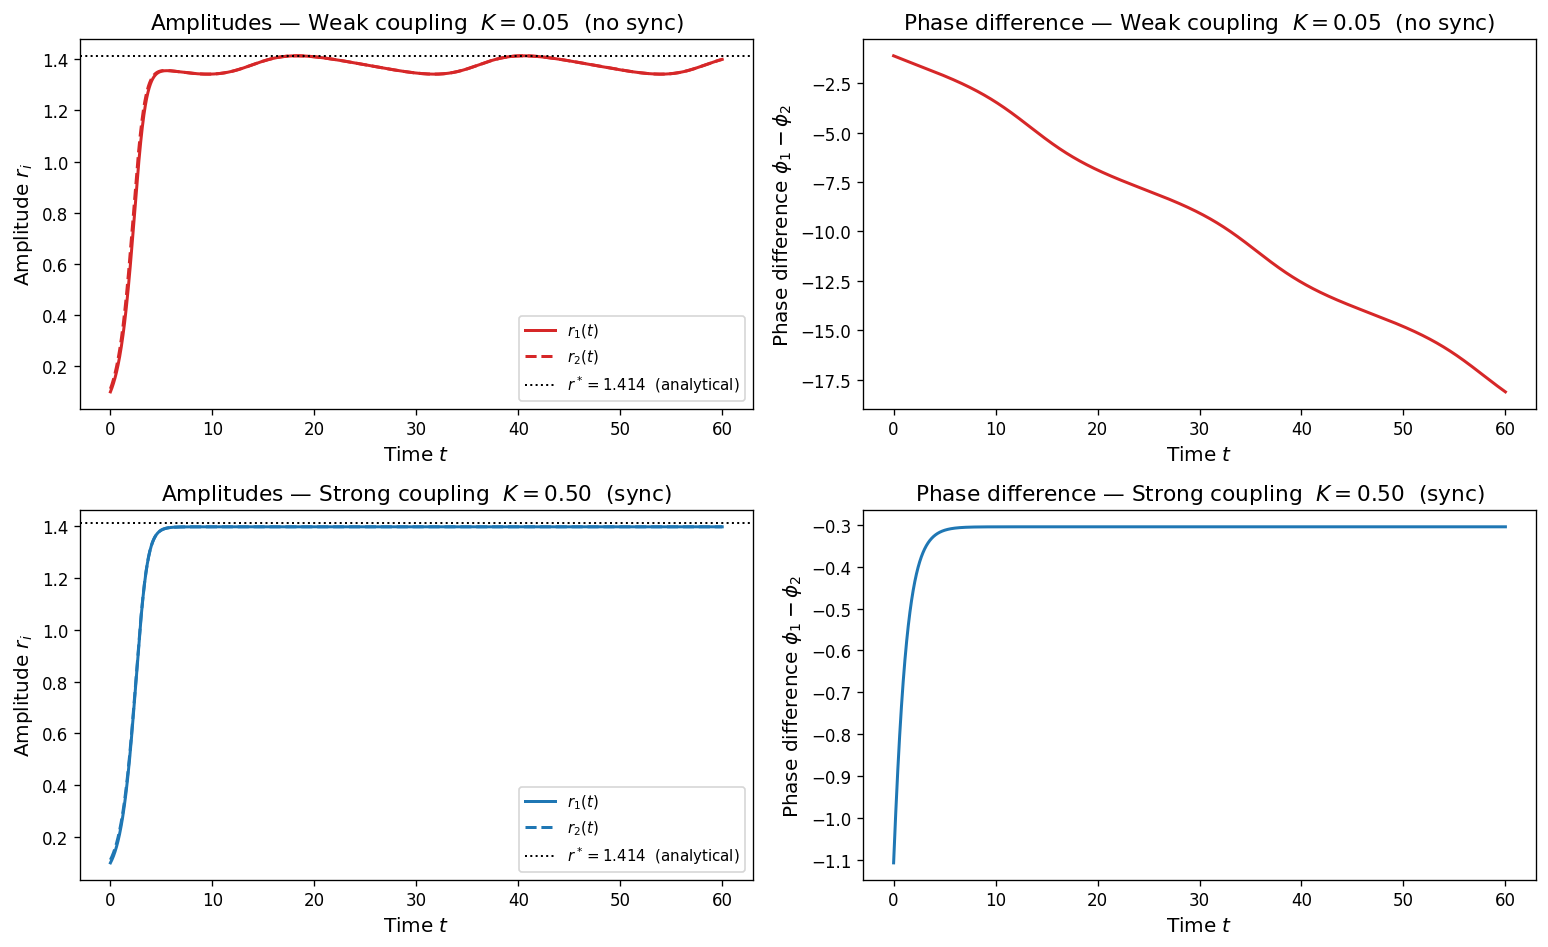

In [12]:
sigma_r  = 1.0
l_r      = 1.0
sigma_i1 = 2.0   # natural frequency of oscillator 1
sigma_i2 = 2.3   # natural frequency of oscillator 2
r_star   = np.sqrt(2 * sigma_r / l_r)
z0       = [0.1, 0.0, 0.05, 0.1]
t_span   = (0, 60)
t_eval   = np.linspace(*t_span, 6000)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

params = [
    (0.05, "Weak coupling  $K = 0.05$  (no sync)",   "C3", axes[0, 0], axes[0, 1]),
    (0.50, "Strong coupling  $K = 0.50$  (sync)",    "C0", axes[1, 0], axes[1, 1]),
]

for K, title, col, ax_r, ax_d in params:
    sol = solve_ivp(
        lambda t, z, K=K: coupled_SL_rhs(t, z, sigma_r, sigma_i1, sigma_i2, l_r, K),
        t_span, z0, t_eval=t_eval, rtol=1e-9)

    x1, y1, x2, y2 = sol.y
    r1   = np.sqrt(x1**2 + y1**2)
    r2   = np.sqrt(x2**2 + y2**2)
    phi1 = np.unwrap(np.arctan2(y1, x1))
    phi2 = np.unwrap(np.arctan2(y2, x2))

    ax_r.plot(sol.t, r1, color=col, label="$r_1(t)$")
    ax_r.plot(sol.t, r2, color=col, ls='--', label="$r_2(t)$")
    ax_r.axhline(r_star, color='k', ls=':', lw=1.2,
                 label=f"$r^* = {r_star:.3f}$  (analytical)")
    ax_r.set(xlabel="Time $t$", ylabel="Amplitude $r_i$", title=f"Amplitudes — {title}")
    ax_r.legend(fontsize=9)

    ax_d.plot(sol.t, phi1 - phi2, color=col)
    ax_d.set(xlabel="Time $t$",
             ylabel=r"Phase difference $\phi_1 - \phi_2$",
             title=f"Phase difference — {title}")

plt.tight_layout()
plt.savefig('2cpld_full_fig1', dpi=300, bbox_inches='tight')
plt.show()

**Observation.**
- **Weak coupling ($K = 0.05$):** amplitudes settle near $r^*$ individually, but the phase difference grows — **no synchronization**. The two generators cannot lock because the transmission line is too weak.
- **Strong coupling ($K = 0.50$):** both amplitudes converge close to $r^*$ *and* the phase difference settles to a constant — **full synchronization**.

Unlike the Kuramoto model, the SL framework captures both amplitude and phase dynamics simultaneously.

### 3.2  Effect of Inertia: Varying $\sigma_r$

In the SL framework, $\sigma_r$ controls how fast the amplitude recovers after a disturbance.
Linearising around $r^*$: $\dot{\varepsilon}_i \approx -2\sigma_r \varepsilon_i$, giving relaxation time $\tau = 1/(2\sigma_r)$.

This provides a natural **inertia proxy**:

$$\text{High inertia} \; (M \text{ large}) \quad \longleftrightarrow \quad \text{Large } \tau = \frac{1}{2\sigma_r} \quad \longleftrightarrow \quad \text{Small } \sigma_r$$

We compare high vs low $\sigma_r$ at the same coupling $K = 0.30$.

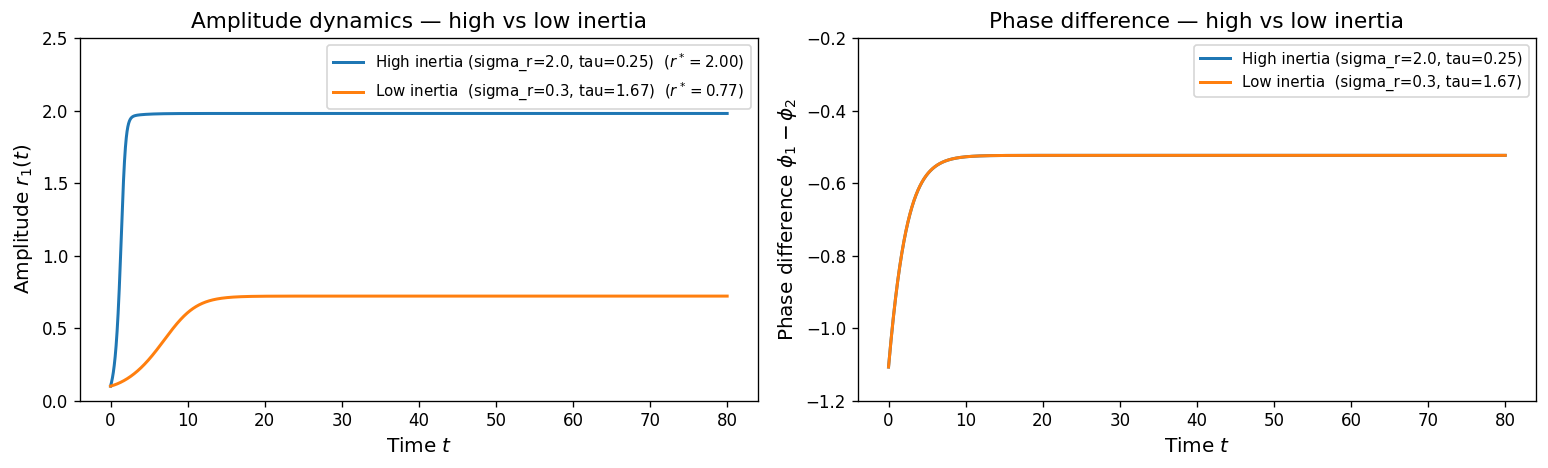

In [18]:
K         = 0.30
sigma_i1  = 2.0
sigma_i2  = 2.3
z0        = [0.1, 0.0, 0.05, 0.1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for sr, col, lab in [(2.0, "C0", "High inertia (sigma_r=2.0, tau={:.2f})".format(1/(2*2.0))),
                     (0.3, "C1", "Low inertia  (sigma_r=0.3, tau={:.2f})".format(1/(2*0.3)))]:
    rstar = np.sqrt(2 * sr / 1.0)
    sol = solve_ivp(
        lambda t, z, sr=sr: coupled_SL_rhs(t, z, sr, sigma_i1, sigma_i2, 1.0, K),
        (0, 80), z0, t_eval=np.linspace(0, 80, 8000), rtol=1e-9)

    x1, y1, x2, y2 = sol.y
    r1   = np.sqrt(x1**2 + y1**2)
    phi1 = np.unwrap(np.arctan2(y1, x1))
    phi2 = np.unwrap(np.arctan2(np.sqrt(x2**2+y2**2)*0 + y2, x2))
    phi2 = np.unwrap(np.arctan2(y2, x2))

    axes[0].plot(sol.t, r1, col, label=f"{lab}  ($r^*={rstar:.2f}$)")
    axes[0].set_ylim(0, 2.50)
    axes[1].plot(sol.t, phi1 - phi2, col, label=lab)
    axes[1].set_ylim(-1.2, -0.20)

axes[0].set(xlabel="Time $t$", ylabel="Amplitude $r_1(t)$",
            title="Amplitude dynamics — high vs low inertia")
axes[0].legend(fontsize=9)
axes[1].set(xlabel="Time $t$",
            ylabel=r"Phase difference $\phi_1 - \phi_2$",
            title="Phase difference — high vs low inertia")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('2cpld_full_fig2', dpi=300, bbox_inches='tight')
plt.show()

**Observation.** Lower $\sigma_r$ (low-inertia regime) means slower amplitude recovery ($\tau$ larger) and slower phase locking.
This is consistent with the known challenge of low-inertia grids: reduced inertia means less natural damping of disturbances, making synchronization harder to maintain and more sensitive to the coupling strength $K$.

---
## Summary

| Part | Model | Key analytical result | Verified numerically? |
|---|---|---|---|
| 1 | Single SL oscillator | $r^* = \sqrt{2\sigma_r/l_r}$; Hopf bifurcation at $\sigma_r=0$ | Yes |
| 2 | Two Kuramoto oscillators | Sync iff $K \geq K_c = \|\Delta\omega\|/2$; angle $\Delta^* = \arcsin(\Delta\omega/2K)$ | Yes |
| 3 | Two coupled SL oscillators | Full amplitude + phase; $\tau = 1/(2\sigma_r)$ as inertia proxy | Yes |

The Stuart–Landau framework generalises the Kuramoto model: the Kuramoto phase equations are recovered exactly on the limit cycle ($r_i = r^*$).
In low-inertia grids, amplitude transients matter, making the full SL model the appropriate tool.